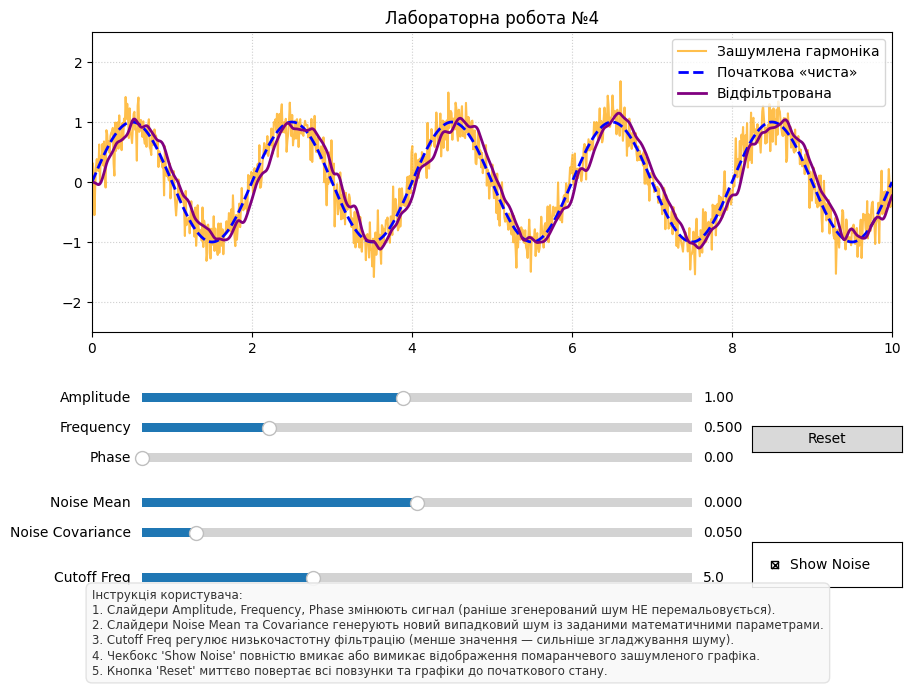

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import iirfilter, lfilter

def harmonic_with_noise(amplitude, frequency, phase, noise_mean, noise_covariance, show_noise=True, global_noise=None):
    t = np.linspace(0, 10, 1000)
    omega = 2 * np.pi * frequency
    y_pure = amplitude * np.sin(omega * t + phase)
    
    if global_noise is None:
        std_dev = np.sqrt(noise_covariance)
        noise = np.random.normal(noise_mean, std_dev, size=len(t))
    else:
        noise = global_noise
        
    y_noisy = y_pure + noise if show_noise else y_pure
    return t, y_pure, y_noisy, noise

def filter_signal(data, cutoff, fs=100.0):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    if normal_cutoff >= 1.0:
        normal_cutoff = 0.99
    b, a = iirfilter(4, normal_cutoff, btype='low', ftype='butter')
    return lfilter(b, a, data)

init_amp = 1.0
init_freq = 0.5
init_phase = 0.0
init_noise_mean = 0.0
init_noise_cov = 0.05
init_cutoff = 5.0

t_init = np.linspace(0, 10, 1000)
current_noise = np.random.normal(init_noise_mean, np.sqrt(init_noise_cov), size=len(t_init))

# Зберігаємо параметри шуму для відстеження змін
last_noise_mean = init_noise_mean
last_noise_cov = init_noise_cov

t, y_pure, y_noisy, _ = harmonic_with_noise(
    init_amp, init_freq, init_phase, init_noise_mean, init_noise_cov, True, current_noise
)
y_filtered = filter_signal(y_noisy, init_cutoff)

# Збільшуємо висоту вікна (figsize до 11), щоб виділити чисте місце знизу
fig, ax = plt.subplots(figsize=(10, 7.5))
plt.subplots_adjust(left=0.1, bottom=0.48)

line_noisy, = ax.plot(t, y_noisy, color='orange', alpha=0.7, label='Зашумлена гармоніка')
line_pure, = ax.plot(t, y_pure, color='blue', linestyle='--', linewidth=2, label='Початкова «чиста»')
line_filtered, = ax.plot(t, y_filtered, color='purple', linewidth=2, label='Відфільтрована')

ax.set_xlim(0, 10)
ax.set_ylim(-2.5, 2.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')
ax.set_title("Лабораторна робота №4", fontsize=12)

# Зсуваємо координати слайдерів трохи вище, звільняючи самий низ під текст
ax_amp = plt.axes([0.15, 0.38, 0.55, 0.025])
ax_freq = plt.axes([0.15, 0.34, 0.55, 0.025])
ax_phase = plt.axes([0.15, 0.30, 0.55, 0.025])
ax_n_mean = plt.axes([0.15, 0.24, 0.55, 0.025])
ax_n_cov = plt.axes([0.15, 0.20, 0.55, 0.025])
ax_cutoff = plt.axes([0.15, 0.14, 0.55, 0.025])

s_amp = Slider(ax_amp, 'Amplitude', 0.1, 2.0, valinit=init_amp, valfmt='%1.2f')
s_freq = Slider(ax_freq, 'Frequency', 0.05, 2.0, valinit=init_freq, valfmt='%1.3f')
s_phase = Slider(ax_phase, 'Phase', 0.0, 2*np.pi, valinit=init_phase, valfmt='%1.2f')
s_n_mean = Slider(ax_n_mean, 'Noise Mean', -0.5, 0.5, valinit=init_noise_mean, valfmt='%1.3f')
s_n_cov = Slider(ax_n_cov, 'Noise Covariance', 0.001, 0.5, valinit=init_noise_cov, valfmt='%1.3f')
s_cutoff = Slider(ax_cutoff, 'Cutoff Freq', 0.5, 15.0, valinit=init_cutoff, valfmt='%1.1f')

ax_check = plt.axes([0.76, 0.14, 0.15, 0.06])
check = CheckButtons(ax_check, ['Show Noise'], [True])

ax_reset = plt.axes([0.76, 0.32, 0.15, 0.035])
btn_reset = Button(ax_reset, 'Reset', hovercolor='0.975')

# Розміщуємо інструкцію в самому низу екрана (y=0.02), де вона нічому не заважає
instruction_text = (
    "Інструкція користувача:\n"
    "1. Слайдери Amplitude, Frequency, Phase змінюють сигнал (раніше згенерований шум НЕ перемальовується).\n"
    "2. Слайдери Noise Mean та Covariance генерують новий випадковий шум із заданими математичними параметрами.\n"
    "3. Cutoff Freq регулює низькочастотну фільтрацію (менше значення — сильніше згладжування шуму).\n"
    "4. Чекбокс 'Show Noise' повністю вмикає або вимикає відображення помаранчевого зашумленого графіка.\n"
    "5. Кнопка 'Reset' миттєво повертає всі повзунки та графіки до початкового стану."
)
fig.text(0.1, 0.02, instruction_text, fontsize=8.5, color='#333333', ha='left', va='bottom',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f9f9', edgecolor='#e0e0e0', alpha=0.9))

def update(val):
    global current_noise, last_noise_mean, last_noise_cov
    
    amp = s_amp.val
    freq = s_freq.val
    phase = s_phase.val
    n_mean = s_n_mean.val
    n_cov = s_n_cov.val
    cutoff = s_cutoff.val
    show_noise = check.get_status()[0]
    
    # Надійна перевірка зміни математичних параметрів шуму
    if n_mean != last_noise_mean or n_cov != last_noise_cov:
        last_noise_mean = n_mean
        last_noise_cov = n_cov
        _, y_p, y_n, current_noise = harmonic_with_noise(amp, freq, phase, n_mean, n_cov, show_noise, global_noise=None)
    else:
        _, y_p, y_n, current_noise = harmonic_with_noise(amp, freq, phase, n_mean, n_cov, show_noise, global_noise=current_noise)
    
    y_f = filter_signal(y_n, cutoff)
    
    line_pure.set_ydata(y_p)
    line_noisy.set_ydata(y_n)
    line_filtered.set_ydata(y_f)
    
    ax.set_ylim(-amp - np.max(np.abs(current_noise)) - 0.2, amp + np.max(np.abs(current_noise)) + 0.2)
    fig.canvas.draw_idle()

s_amp.on_changed(update)
s_freq.on_changed(update)
s_phase.on_changed(update)
s_n_mean.on_changed(update)
s_n_cov.on_changed(update)
s_cutoff.on_changed(update)

def update_checkbox(label):
    update(None)

check.on_clicked(update_checkbox)

def reset_sliders(event):
    global current_noise, last_noise_mean, last_noise_cov
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_n_mean.reset()
    s_n_cov.reset()
    s_cutoff.reset()
    last_noise_mean = init_noise_mean
    last_noise_cov = init_noise_cov
    current_noise = np.random.normal(init_noise_mean, np.sqrt(init_noise_cov), size=len(t_init))
    if not check.get_status()[0]:
        check.set_active(0)
    update(None)

btn_reset.on_clicked(reset_sliders)

plt.show()